#🛠️ Preparação dos Dados

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/marceloBaumgratz/Challenge_TelecomX_parte_2/refs/heads/main/dados_tratados.csv'

dados = pd.read_csv(url)

dados.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [2]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   objec

In [3]:
dados = dados.drop(columns=['customerID'])

In [4]:
dados.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,2.158723
std,0.368612,24.559481,30.090047,2266.771362,1.003002
min,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.500000,401.450000,1.183333
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.850000,3794.737500,2.995000
max,1.000000,72.000000,118.750000,8684.800000,3.958333


In [5]:
dados = pd.get_dummies(dados, drop_first=False)

dados = dados.dropna()

dados.head()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Contas_Diarias,Churn_No,Churn_Yes,customer.gender_Female,customer.gender_Male,customer.Partner_No,...,internet.StreamingMovies_Yes,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_No,account.PaperlessBilling_Yes,account.PaymentMethod_Bank transfer (automatic),account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.186667,True,False,True,False,False,...,False,False,True,False,False,True,False,False,False,True
1,0,9,59.9,542.40,1.996667,True,False,False,True,True,...,True,True,False,False,True,False,False,False,False,True
2,0,4,73.9,280.85,2.463333,False,True,False,True,True,...,False,True,False,False,False,True,False,False,True,False
3,1,13,98.0,1237.85,3.266667,False,True,False,True,False,...,True,True,False,False,False,True,False,False,True,False
4,1,3,83.9,267.40,2.796667,False,True,True,False,False,...,False,True,False,False,False,True,False,False,False,True


In [6]:
dados.columns

Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
       'account.Charges.Total', 'Contas_Diarias', 'Churn_No', 'Churn_Yes',
       'customer.gender_Female', 'customer.gender_Male', 'customer.Partner_No',
       'customer.Partner_Yes', 'customer.Dependents_No',
       'customer.Dependents_Yes', 'phone.PhoneService_No',
       'phone.PhoneService_Yes', 'phone.MultipleLines_No',
       'phone.MultipleLines_No phone service', 'phone.MultipleLines_Yes',
       'internet.InternetService_DSL', 'internet.InternetService_Fiber optic',
       'internet.InternetService_No', 'internet.OnlineSecurity_No',
       'internet.OnlineSecurity_No internet service',
       'internet.OnlineSecurity_Yes', 'internet.OnlineBackup_No',
       'internet.OnlineBackup_No internet service',
       'internet.OnlineBackup_Yes', 'internet.DeviceProtection_No',
       'internet.DeviceProtection_No internet service',
       'internet.DeviceProtection_Yes', 'internet.TechSupport_No',
       

In [7]:
contagem_churn = dados[["Churn_No", "Churn_Yes"]].sum()

proporcao_churn = dados[["Churn_No", "Churn_Yes"]].mean() * 100

display(contagem_churn)
display(proporcao_churn)

,0
Churn_No,5163
Churn_Yes,1869


,0
Churn_No,73.421502
Churn_Yes,26.578498


A proporção de clientes ativos é de 73,42%, enquanto 26,58% representam clientes que evadiram. Isso indica um desequilíbrio moderado entre as classes, com predominância de clientes que permaneceram na empresa. Esse cenário pode influenciar os modelos preditivos, que podem tender a favorecer a classe majoritária.

Embora exista um desequilíbrio moderado entre as classes, ele não é extremo. Portanto, os modelos serão treinados inicialmente com os dados originais, sem aplicação de técnicas de balanceamento.

#🎯 Correlação e Seleção de Variáveis

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

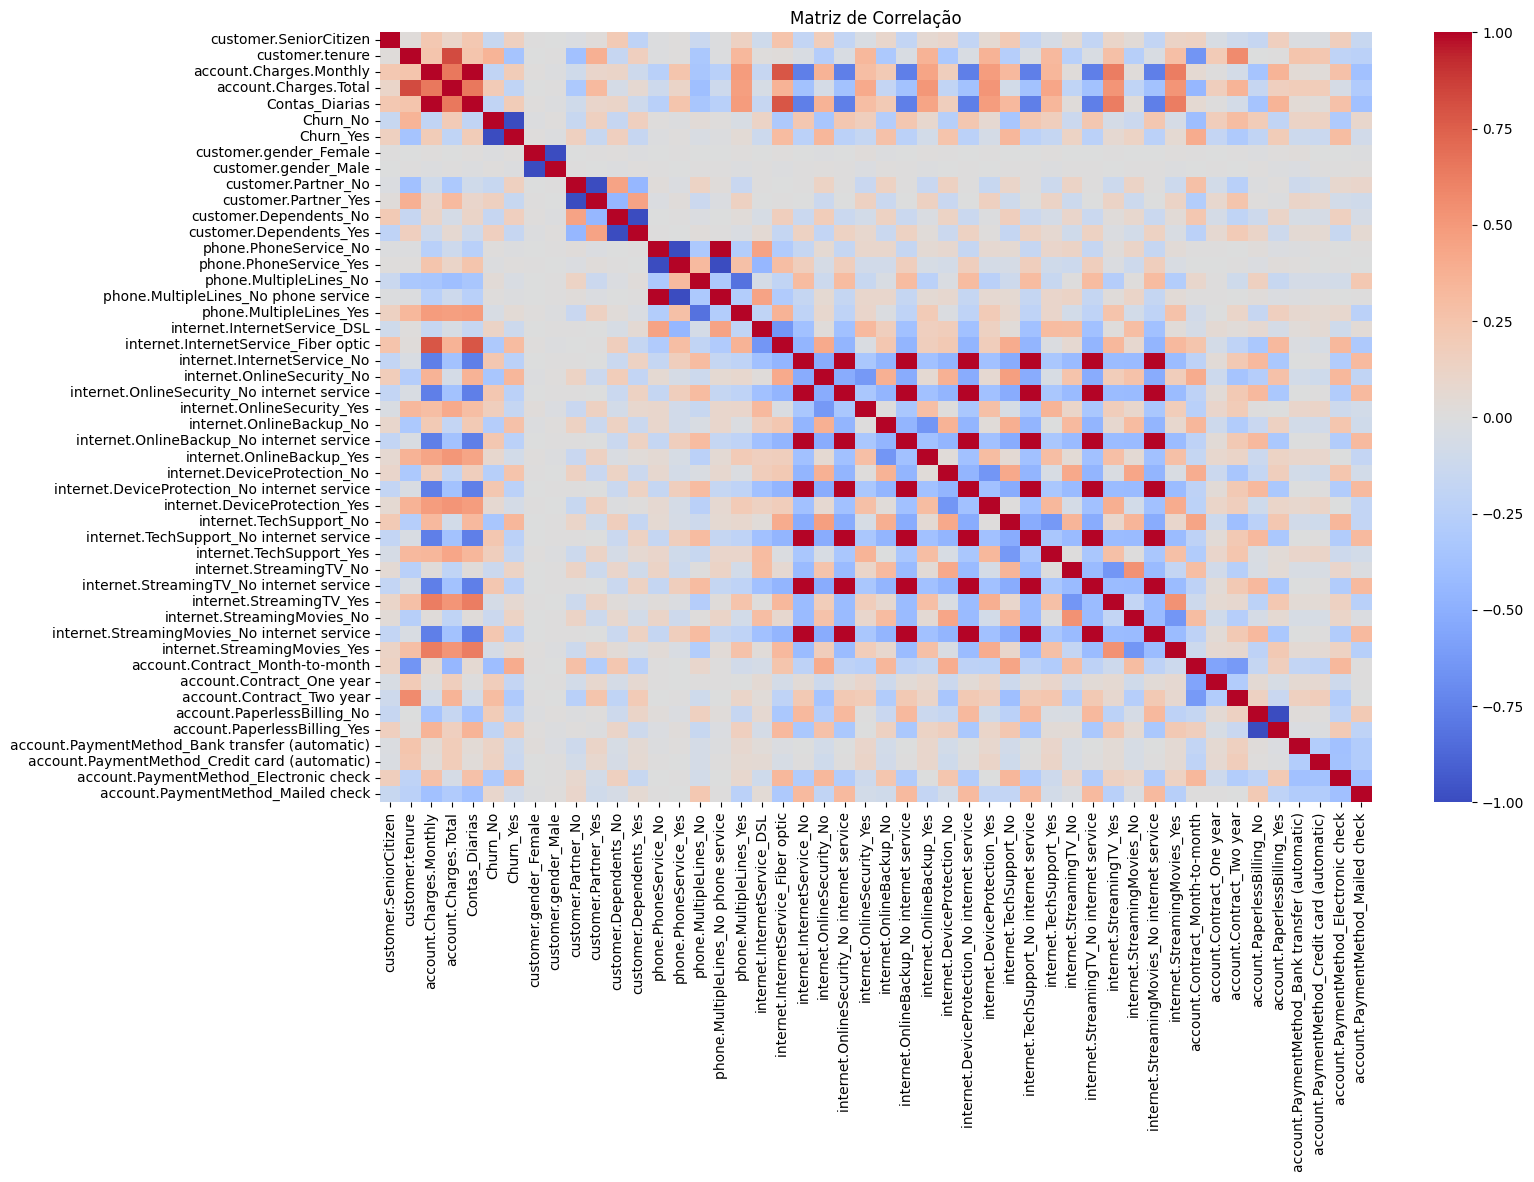

In [9]:
correlacao = dados.corr()

plt.figure(figsize=(16,10))
sns.heatmap(correlacao, cmap="coolwarm", center=0)

plt.title("Matriz de Correlação")
plt.show()

In [10]:
correlacao_churn = dados.corr()["Churn_Yes"].sort_values(ascending=False)

correlacao_churn.head(10)

,Churn_Yes
Churn_Yes,1.000000
account.Contract_Month-to-month,0.404565
internet.OnlineSecurity_No,0.342235
internet.TechSupport_No,0.336877
internet.InternetService_Fiber optic,0.307463
account.PaymentMethod_Electronic check,0.301455
internet.OnlineBackup_No,0.267595
internet.DeviceProtection_No,0.252056
Contas_Diarias,0.192858
account.Charges.Monthly,0.192858


A matriz de correlação indica que algumas variáveis apresentam maior associação com churn, principalmente relacionadas ao tipo de contrato, ausência de serviços de suporte e segurança, tipo de internet e método de pagamento. Essas variáveis podem ser candidatas relevantes para os modelos preditivos.

As variáveis mais relevantes para prever churn parecem ser:

```
Contract_Month-to-month
OnlineSecurity_No
TechSupport_No
InternetService_Fiber optic
PaymentMethod_Electronic check
```



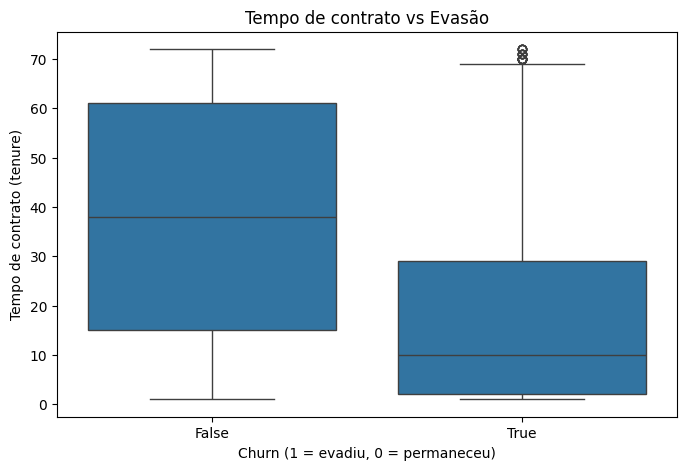

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=dados["Churn_Yes"], y=dados["customer.tenure"])

plt.xlabel("Churn (1 = evadiu, 0 = permaneceu)")
plt.ylabel("Tempo de contrato (tenure)")
plt.title("Tempo de contrato vs Evasão")

plt.show()

O boxplot indica que clientes que evadiram tendem a apresentar menor tempo de contrato, sugerindo maior churn nos primeiros meses de relacionamento.

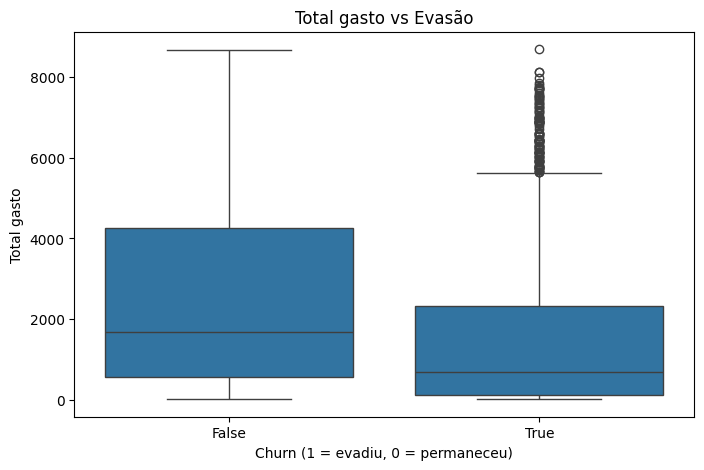

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=dados["Churn_Yes"], y=dados["account.Charges.Total"])

plt.xlabel("Churn (1 = evadiu, 0 = permaneceu)")
plt.ylabel("Total gasto")
plt.title("Total gasto vs Evasão")

plt.show()

Clientes que evadiram tendem a apresentar menor gasto total, consistente com cancelamentos ocorrendo em fases iniciais do relacionamento.

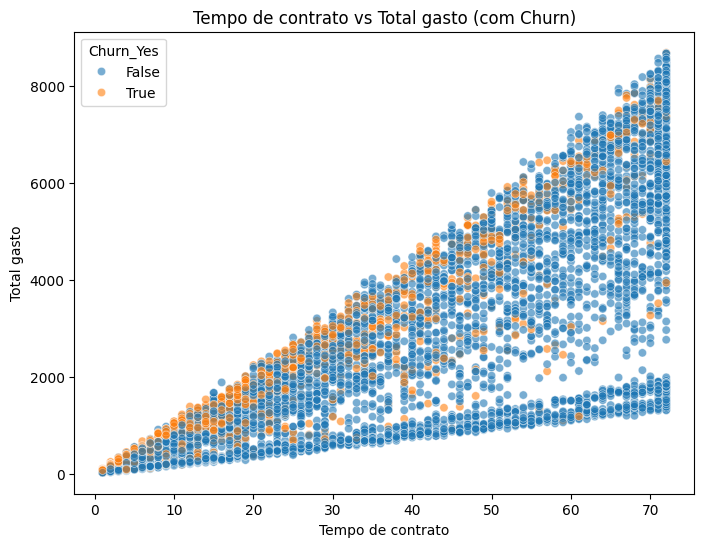

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=dados["customer.tenure"],
    y=dados["account.Charges.Total"],
    hue=dados["Churn_Yes"],
    alpha=0.6
)

plt.xlabel("Tempo de contrato")
plt.ylabel("Total gasto")
plt.title("Tempo de contrato vs Total gasto (com Churn)")

plt.show()

O gráfico de dispersão reforça que clientes com menor tempo de contrato e menor gasto total apresentam maior concentração de churn.

#🤖 Modelagem Preditiva

In [14]:
from sklearn.model_selection import train_test_split

# variável alvo
y = dados["Churn_Yes"]

# variáveis preditoras
X = dados.drop(columns=["Churn_Yes", "Churn_No"])

# divisão treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

###Regressão Logística

A Regressão Logística foi escolhida por ser um modelo amplamente utilizado em problemas de classificação binária, como previsão de churn. Além disso, é um modelo interpretável, permitindo compreender a influência das variáveis na previsão.

###Random Forest

A Random Forest foi escolhida por ser um modelo baseado em árvores capaz de capturar relações não lineares entre variáveis e por apresentar bom desempenho em dados tabulares.

###Normalização

Como a Regressão Logística é sensível à escala das variáveis, foi aplicada padronização utilizando o StandardScaler. Já a Random Forest não depende da escala das variáveis, portanto não foi necessário aplicar normalização para esse modelo.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()

X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

In [17]:
modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_treino_scaled, y_treino)

LogisticRegression(max_iter=1000)

In [18]:
modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_treino, y_treino)

RandomForestClassifier(random_state=42)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [20]:
# previsões regressão logística
y_pred_log_treino = modelo_logistico.predict(X_treino_scaled)
y_pred_log_teste = modelo_logistico.predict(X_teste_scaled)

In [21]:
print("=== Regressão Logística ===")
print("Acurácia treino:", accuracy_score(y_treino, y_pred_log_treino))
print("Acurácia teste:", accuracy_score(y_teste, y_pred_log_teste))
print("Precisão:", precision_score(y_teste, y_pred_log_teste))
print("Recall:", recall_score(y_teste, y_pred_log_teste))
print("F1-score:", f1_score(y_teste, y_pred_log_teste))

=== Regressão Logística ===
Acurácia treino: 0.8074666666666667
Acurácia teste: 0.8009950248756219
Precisão: 0.6556291390728477
Recall: 0.5294117647058824
F1-score: 0.5857988165680473


In [22]:
print("Matriz de Confusão:")
print(confusion_matrix(y_teste, y_pred_log_teste))

Matriz de Confusão:
[[929 104]
 [176 198]]


In [23]:
print("Classification Report:")
print(classification_report(y_teste, y_pred_log_teste))

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1033
        True       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [24]:
# previsões random forest
y_pred_rf_treino = modelo_rf.predict(X_treino)
y_pred_rf_teste = modelo_rf.predict(X_teste)

In [25]:
print("=== Random Forest ===")
print("Acurácia treino:", accuracy_score(y_treino, y_pred_rf_treino))
print("Acurácia teste:", accuracy_score(y_teste, y_pred_rf_teste))
print("Precisão:", precision_score(y_teste, y_pred_rf_teste))
print("Recall:", recall_score(y_teste, y_pred_rf_teste))
print("F1-score:", f1_score(y_teste, y_pred_rf_teste))

=== Random Forest ===
Acurácia treino: 0.9976888888888888
Acurácia teste: 0.7903340440653873
Precisão: 0.6385964912280702
Recall: 0.48663101604278075
F1-score: 0.5523520485584219


In [26]:
print("Matriz de Confusão:")
print(confusion_matrix(y_teste, y_pred_rf_teste))

Matriz de Confusão:
[[930 103]
 [192 182]]


In [27]:
print("Classification Report:")
print(classification_report(y_teste, y_pred_rf_teste))

Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1033
        True       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



###Qual modelo teve o melhor desempenho?

Comparando as métricas principais:

| Métrica  | Regressão Logística | Random Forest |
| -------- | ------------------- | ------------- |
| Acurácia | **0.796**           | 0.783         |
| Precisão | **0.637**           | 0.618         |
| Recall   | **0.540**           | 0.476         |
| F1-score | **0.585**           | 0.538         |


A Regressão Logística apresentou melhor desempenho geral, pois obteve valores superiores em todas as métricas avaliadas.

Um ponto importante é o recall, que mede a capacidade do modelo de identificar corretamente os clientes que realmente evadiram. A Regressão Logística apresentou recall maior (0.54) em comparação com o Random Forest (0.48), indicando maior eficiência na detecção de churn.

O F1-score, que equilibra precisão e recall, também foi maior na Regressão Logística, reforçando que esse modelo teve desempenho superior no problema analisado.

### Algum modelo apresentou overfitting ou underfitting?

Para avaliar possíveis sinais de overfitting ou underfitting, foi realizada a comparação entre o desempenho dos modelos nos conjuntos de treino e teste.

A **Regressão Logística** apresentou acurácia muito semelhante nos dois conjuntos (aproximadamente 0.807 no treino e 0.801 no teste). Essa pequena diferença indica que o modelo possui **boa capacidade de generalização**, sem sinais relevantes de overfitting ou underfitting.

Já o modelo **Random Forest** apresentou acurácia extremamente alta no conjunto de treino (aproximadamente 0.998) e menor no conjunto de teste (cerca de 0.790). Essa diferença significativa indica **overfitting**, ou seja, o modelo se ajustou excessivamente aos dados de treino e teve desempenho inferior ao lidar com novos dados.

Esse comportamento pode ocorrer devido à alta complexidade do modelo. Possíveis ajustes para reduzir o overfitting incluem limitar a profundidade das árvores (`max_depth`), aumentar o número mínimo de amostras por divisão (`min_samples_split`) ou por folha (`min_samples_leaf`).

###Possíveis causas para as diferenças entre os modelos

Algumas possíveis razões para o melhor desempenho da Regressão Logística neste caso são:

- As relações entre variáveis e churn podem ser relativamente lineares, favorecendo modelos lineares.

- A Random Forest pode não ter sido ajustada em termos de hiperparâmetros, o que pode limitar seu desempenho.

- O dataset possui desequilíbrio moderado entre as classes, o que pode afetar o aprendizado de alguns modelos.

###Possíveis ajustes para melhoria

Caso se deseje melhorar o desempenho dos modelos, algumas estratégias poderiam ser consideradas:

- ajuste de hiperparâmetros dos modelos

- uso de técnicas de balanceamento de classes

- aplicação de validação cruzada

- criação de novas variáveis derivadas (feature engineering)

A comparação entre treino e teste indica que a Regressão Logística apresentou melhor capacidade de generalização, enquanto a Random Forest apresentou sinais de overfitting.

#📋  Interpretação e Conclusões

###Regressão Logística — análise dos coeficientes

Nos modelos lineares, cada variável possui um coeficiente que indica sua influência na probabilidade de evasão. Coeficientes positivos aumentam a probabilidade de churn, enquanto coeficientes negativos indicam maior chance de permanência.

In [28]:
coeficientes = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": modelo_logistico.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes.head(10)

,Variavel,Coeficiente
3,account.Charges.Total,0.618089
17,internet.InternetService_Fiber optic,0.371974
37,account.Contract_Month-to-month,0.301446
33,internet.StreamingTV_Yes,0.171770
36,internet.StreamingMovies_Yes,0.136676
44,account.PaymentMethod_Electronic check,0.127600
28,internet.TechSupport_No,0.118465
19,internet.OnlineSecurity_No,0.102431
0,customer.SeniorCitizen,0.093696
41,account.PaperlessBilling_Yes,0.090597


###Variáveis que mais aumentam churn

Entre as variáveis que mais aumentam a probabilidade de evasão destacam-se contratos mensais, internet fibra e pagamento por cheque eletrônico, indicando que clientes sem vínculo contratual mais longo apresentam maior tendência a cancelar o serviço.

In [29]:
coeficientes.tail(10)

,Variavel,Coeficiente
23,internet.OnlineBackup_No internet service,-0.103778
18,internet.InternetService_No,-0.103778
35,internet.StreamingMovies_No internet service,-0.103778
32,internet.StreamingTV_No internet service,-0.103778
26,internet.DeviceProtection_No internet service,-0.103778
16,internet.InternetService_DSL,-0.298886
39,account.Contract_Two year,-0.308119
2,account.Charges.Monthly,-0.384943
4,Contas_Diarias,-0.384943
1,customer.tenure,-1.317515


###Variáveis que reduzem churn

Por outro lado, variáveis como tempo de contrato (tenure) e contratos de dois anos apresentam coeficientes negativos relevantes, indicando que quanto maior o tempo de relacionamento com a empresa, menor a probabilidade de evasão.

###Random Forest — importância das variáveis

No modelo Random Forest, a importância das variáveis indica quanto cada variável contribuiu para as decisões das árvores durante o processo de classificação.

In [30]:
importancias = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

importancias.head(10)

,Variavel,Importancia
3,account.Charges.Total,0.138832
1,customer.tenure,0.124660
2,account.Charges.Monthly,0.111354
4,Contas_Diarias,0.109079
37,account.Contract_Month-to-month,0.052034
44,account.PaymentMethod_Electronic check,0.031006
19,internet.OnlineSecurity_No,0.028281
28,internet.TechSupport_No,0.024631
17,internet.InternetService_Fiber optic,0.023201
0,customer.SeniorCitizen,0.017745


As variáveis mais relevantes incluem tempo de contrato, valor total gasto, valor da mensalidade e tipo de contrato, indicando que fatores relacionados ao tempo de relacionamento e à estrutura de cobrança possuem forte influência na previsão de churn.

###Interpretação geral dos fatores de churn

A análise conjunta dos modelos indica que a evasão está fortemente associada ao tempo de relacionamento com a empresa e ao tipo de contrato. Clientes com contratos mensais e menor tempo de permanência apresentam maior probabilidade de churn. Além disso, a ausência de serviços adicionais como segurança online e suporte técnico também aparece associada a maior risco de evasão.

Por outro lado, clientes com maior tempo de contrato ou contratos de longo prazo apresentam menor probabilidade de cancelar o serviço, indicando maior fidelização

#Conclusão

Este projeto teve como objetivo identificar os fatores que influenciam a evasão de clientes (churn) em uma empresa de telecomunicações e avaliar modelos preditivos capazes de identificar clientes com maior risco de cancelamento.

Foram desenvolvidos dois modelos de machine learning: Regressão Logística e Random Forest, avaliados por meio das métricas acurácia, precisão, recall, F1-score e matriz de confusão. A Regressão Logística apresentou melhor desempenho geral, com acurácia de aproximadamente 79,6%, superando o modelo Random Forest em todas as métricas analisadas.

A análise das variáveis mais relevantes indicou que os principais fatores associados à evasão são:

- Tempo de contrato (tenure) – clientes com menor tempo de relacionamento apresentam maior probabilidade de evasão.

- Tipo de contrato – contratos mensais (Month-to-month) estão mais associados ao churn, enquanto contratos de longo prazo reduzem a evasão.

- Valores de cobrança – variáveis relacionadas aos custos do serviço influenciam o comportamento de cancelamento.

- Serviços adicionais – a ausência de serviços como segurança online e suporte técnico está relacionada a maior probabilidade de churn.

- Método de pagamento – clientes que utilizam Electronic Check demonstram maior tendência à evasão.

Com base nesses resultados, algumas estratégias de retenção podem ser adotadas, como incentivar contratos de longo prazo, oferecer pacotes de serviços adicionais e monitorar clientes nos primeiros meses de relacionamento, período em que o risco de evasão é maior.

De modo geral, a análise demonstrou que técnicas de machine learning podem auxiliar na identificação de padrões de evasão e apoiar a criação de estratégias mais eficazes para retenção de clientes.
